## <center> Simple KNN implementation </center>

---
## Instructions

### Summary of Work:
- Problem 1: Implementing kMeans 
    - Problem 1.1: compute_membership 
    - Problem 1.2: initialize_clusters 
    - Problem 1.3: update_centroids 
    - Problem 1.4: fit 
- Problem 2: Experimenting with kMeans 
    - Problem 2.1: Varying k  
    - Problem 2.2: Random initialization 
    - Problem 2.3: Kmeans++ initialization 
- Statement of Collaboration 

Before we get started, let's import some libraries that you will make use of in this assignment. Make sure that you run the code cell below in order to import these libraries.

**Important: In the code block below, we set `seed=1234`. This is to ensure your code has reproducible results and is important for grading. Do not change this. If you are not using the provided Jupyter notebook, make sure to also set the random seed as below.**

**Important: Do not change any codes we give you below, except for those waiting for you to complete. This is to ensure your code has reproducible results and is important for grading.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.datasets import load_wine

# Fix the random seed for reproducibility
# !! Important !! : do not change this
seed = 1234
np.random.seed(seed)

---
## Problem 1: Implementing kMeans

In this problem you will implement the k-means clustering algorithm. Below, you are given some starter code which partially implements the class `KMeansClustering`, which defines a k-means clustering model.

Let's also load in some data that we will use for the tests in Problem 1. Here, we are using the wine dataset, where we're only using the first two features. Although you typically would split your data into a training set and a testing set, we won't do that here because we are only using this data to create some tests for your implementation.

In [2]:
# JUST RUN - DO NOT EDIT THIS CODE BLOCK
# Set numpy seed
np.random.seed(seed)
# Load in the wine dataset
wine = load_wine(as_frame=True)
wine_df = wine.frame # pandas dataframe

# Select the necessary features and clean the data.
wine_attributes = ['alcohol', 'od280/od315_of_diluted_wines', 'target']
new_wine_df = wine_df[wine_attributes].copy().dropna()

shuffled_wine_df = new_wine_df.sample(frac=1, random_state=seed)

# Split the data into x and y.
X = shuffled_wine_df[['alcohol', 'od280/od315_of_diluted_wines']].to_numpy()
y = shuffled_wine_df['target'].astype("category").to_numpy()


In [3]:
class KMeansClustering:
    """
    A class representing a k-means clustering algorithm.
    """

    def __init__(self, k, init_strategy, random_state=None):
        np.random.seed(random_state) # Sets the random seed of your implementation
        self.k = k  # Number of clusters
        self.centroids = None  # A numpy array containing the center of each cluster
        assert init_strategy in ['random', 'kmeans++'], 'Did not receive a valid initialization strategy.'
        self.init_strategy = init_strategy # The strategy that the algorithm will use to initialize centroids

    def compute_memberships(self, X, centroids):
        """
        Given a feature matrix X and an array of centroids,
            compute the cluster assignment for each datapoint in X.

        X: numpy array of shape (n, d) where n is the number of datapoints and d is the number of features
        centroids: numpy array of shape (k, d) where k is the number of clusters and d is the number of features

        Returns:
        which_cluster: numpy array of shape (n, ) containing the cluster assignment for each data point in X
        squared_distances: numpy array of shape (n, ) containing the squared distance between each data point in X
            and the centroid of its corresponding cluster
        """
        squared_distances = []
        which_cluster = []
        
        ### YOUR CODE STARTS HERE ###
        for x in X:
            distances = np.sum((centroids - x) ** 2, axis=1)  # Euclidean squared distances
            cluster_idx = np.argmin(distances)  # Closest centroid index
            which_cluster.append(cluster_idx)
            squared_distances.append(distances[cluster_idx])
        ### YOUR CODE ENDS HERE ###

        which_cluster = np.asarray(which_cluster)
        squared_distances = np.asarray(squared_distances)
        return which_cluster, squared_distances

    def initialize_clusters(self, X):
        """
        Computes the initial clusters based on a feature matrix X.

        X: numpy array of shape (n, d) where n is the number of datapoints and d is the number of features

        Returns:
        centroids: numpy array of shape (k, d) where k is the number of clusters and d is the number of features,
            corresponding to the initial clusters chosen by the appropriate strategy
        """
        if self.init_strategy == 'random':
            n_rows = X.shape[0]
            # Randomly select k rows using np.random.choice().
            rows = np.random.choice(n_rows, self.k, replace=False)
            # Get the randomly selected rows from X.
            centroids = X[rows]
            return np.asarray(centroids)
        elif self.init_strategy == 'kmeans++':
            n_rows = X.shape[0]
            centroids = []
            
            # Randomly select index of first centroid.
            first_idx = np.random.choice(n_rows)
            # Get corresponding row from X.
            first_centroid = X[first_idx]
            centroids.append(first_centroid)

            for i in range(self.k - 1):
                # Get distance^2 from each datapoint to nearest centroid.
                _, squared_distances = self.compute_memberships(X, np.array(centroids))
                # Turn into probability distrubtion.
                probs = squared_distances / np.sum(squared_distances)
                # Sample a new centroid using np.random.choice().
                idx = np.random.choice(n_rows, p=probs)
                centroid = X[idx]
                centroids.append(centroid)
            return np.asarray(centroids)

    def update_centroids(self, X, which_cluster):
        """
        Updates the centroid locations based on a feature matrix X and cluster assignments which_cluster.

        X: numpy array of shape (n, d) where n is the number of datapoints and d is the number of features
        which_cluster: numpy array of shape (n, ) where n is the number of datapoints,
            corresponding to the cluster assignments of the datapoints in X

        Returns:
        centroids: numpy array of shape (k, d) where k is the number of clusters and d is the number of features,
            where each centroid corresponds to the mean of the feature vectors in the corresponding cluster.
        """
        new_centroids = []
        ### YOUR CODE STARTS HERE ###
        for i in range(self.k):
            points_in_cluster = X[which_cluster == i]
            if len(points_in_cluster) > 0:
                centroid = np.mean(points_in_cluster, axis=0)
            else:
                # Reinitialize to random point if cluster is empty
                centroid = X[np.random.choice(X.shape[0])]
            new_centroids.append(centroid)
        ### YOUR CODE ENDS HERE ###
        return np.asarray(new_centroids)
        

    def fit(self, X, max_iter=100):
        """
        Fits the k-means clustering algorithm.

        X: numpy array of shape (n, d) where n is the number of datapoints and d is the number of features,
            corresponding to our training data.
        """
        centroids = self.initialize_clusters(X)
        which_cluster, _ = self.compute_memberships(X, centroids)

        converged = False
        i = 0 # Iteration counter
        while not converged:
            new_centroids = self.update_centroids(X, which_cluster)
            new_which_cluster, _ = self.compute_memberships(X, new_centroids)

            # We have reached convergence if the cluster assignments don't change,
            # or if we reach the maximum number of iterations.
            if np.array_equal(which_cluster, new_which_cluster):
                converged = True
            if i == max_iter:
                converged = True
            centroids = new_centroids
            which_cluster = new_which_cluster
            i += 1

        self.centroids = centroids

### Problem 1.1 - compute_memberships 

- Complete the function `compute_memberships`. This function should take in a feature matrix `X` and a numpy array `centroids` containing `k` centroids, i.e. the centers of our clusters. The function should return two things: (1) a numpy array containing the index of which centroid is closest to each datapoint in `X`, and (2) a numpy array containing the squared Euclidean distance to the nearest centroid for each point in `X`.
- Run the code block given below to test your implementation. If your code is correct, all sanity checks should pass.

In [4]:
# Use this code block to test your implementation in Problem 1.1
# Don't change anything here -- just run it

kmeans = KMeansClustering(2, 'random', random_state=seed)
c = np.array([[12.2, 2.5], [13.5, 2.5]])
which_cluster, squared_distances = kmeans.compute_memberships(X[:5], c)
expected_centroid = np.array([0, 1, 0, 0, 1])
expected_sq_dist = np.array([0.1808, 0.5625, 0.1658, 0.3761, 0.0205])
print(f'Sanity Check 1a passed: {np.array_equal(which_cluster, expected_centroid)}')
print(f'Sanity Check 1b passed: {np.allclose(squared_distances, expected_sq_dist, rtol=1e-4, atol=1e-4)}')

kmeans = KMeansClustering(4, 'random', random_state=seed)
c = np.array([[11, 3], [12, 2], [13.5, 3.5], [14, 3]])
which_cluster, squared_distances = kmeans.compute_memberships(X[:5], c)
expected_centroid = np.array([1, 2, 1, 0, 3])
expected_sq_dist = np.array([0.8788, 0.3625, 0.8938, 0.4721, 0.6905])
print(f'Sanity Check 2a passed: {np.array_equal(which_cluster, expected_centroid)}')
print(f'Sanity Check 2b passed: {np.allclose(squared_distances, expected_sq_dist, rtol=1e-4, atol=1e-4)}')

Sanity Check 1a passed: True
Sanity Check 1b passed: True
Sanity Check 2a passed: True
Sanity Check 2b passed: True


### Problem 1.2 - initialize_clusters

- Complete the function `initialize_clusters`. This function takes in a feature matrix `X` and returns a numpy array containing `k` initial centroids. You will implement two different strategies for initialization.
- The first strategy is called `random`, where you will randomly choose `k` data points from the feature matrix `X`. Be careful not to choose the same datapoint twice! Hint: you may find the function `np.random.choice` helpful.
- The second strategy is called `kmeans++`. This strategy typically results in better clusters than the `random` strategy. In some more detail, `kmeans++` works as follows:
    1. Choose the first centroid as a random datapoint from your feature matrix $X$.
    2. For the remaining initial centroids $i = 2, 3, \dots, k$:
        1. For every datapoint $x$ in $X$, compute the squared Euclidean distance from $x$ to the nearest centroid that has already been initialized. This gives you a vector $D$ containing these squared distances.
        2. Compute a probability vector by normalizing $D$, i.e. divide each entry in $D$ by the sum total of all the entries in $D$. Call this probability vector $P$.
        3. Randomly choose your new initial centroid by sampling from $X$, where we select the $j$ th datapoint from $X$ with probability $P[j]$. The function `np.random.choice` has an argument `p` that will assist you with this.


- Run the code block given below to test your implementation. If your code is correct, all sanity checks should pass.


In [5]:
# Use this code block to test your implementation in Problem 1.2
# Don't change anything here -- just run it

kmeans = KMeansClustering(3, 'random', random_state=seed)
init_centroids = kmeans.initialize_clusters(X)
expected = np.array([[13.84,  1.64], [12.37,  2.77], [13.28,  2.78]])
print(f'Sanity Check 1 passed: {np.array_equal(expected, init_centroids)}')

kmeans = KMeansClustering(3, 'kmeans++', random_state=seed)
init_centroids = kmeans.initialize_clusters(X)
expected = np.array([[13.23,  1.51], [13.76,  3.  ], [11.66,  2.14]])
print(f'Sanity Check 2 passed: {np.array_equal(expected, init_centroids)}')

Sanity Check 1 passed: True
Sanity Check 2 passed: True


### Problem 1.3 - update_centroids

- Complete the function `update_centroids`. This function takes in a feature matrix `X` and a numpy array `which_cluster` that contains the cluster assignment for each data point in `X`. Note that, in the lecture, we used $Z$ to denote the cluster assignments, i.e. `which_cluster`. The function should return a new numpy array consisting of `k` centroids, where the `i`th returned centroid is the centroid of all datapoints assigned to cluster `i` by `which_cluster`. In this assigment, the clusters are zero-indexed, i.e. if $k=2$ then your cluster assignments should take values `0` or `1`.
- Run the code block given below to test your implementation. If your code is correct, all sanity checks should pass.

In [6]:
# Use this code block to test your implementation in Problem 1.3
# Don't change anything here -- just run it

kmeans = KMeansClustering(2, 'random', random_state=seed)
which_cluster = np.array([0, 1, 0, 0, 1]) 
centroids = kmeans.update_centroids(X[:5], which_cluster)
expected_centroids = np.array([[12.17666667, 2.8], [13.205, 2.785]])
print(f'Sanity Check 1 passed: {np.allclose(centroids, expected_centroids, rtol=1e-3, atol=1e-3)}')

kmeans = KMeansClustering(4, 'random', random_state=seed)
which_cluster = np.array([1, 2, 1, 0, 3])
centroids = kmeans.update_centroids(X[:5], which_cluster)
expected_centroids = np.array([[11.64, 2.75], [12.445, 2.825], [13.05, 3.1], [13.36, 2.47]])
print(f'Sanity Check 2 passed: {np.allclose(centroids, expected_centroids, rtol=1e-3, atol=1e-3)}')

Sanity Check 1 passed: True
Sanity Check 2 passed: True


### Problem 1.4 - fit 

- Complete the function `fit`. This function takes in a feature matrix `X` and runs the k-means clustering algorithm in order to fit `k` centroids to the data.
- Run the code block given below to test your implementation. If your code is correct, all sanity checks should pass.

Sanity Check 1 passed: True
2 Cluster Plot:


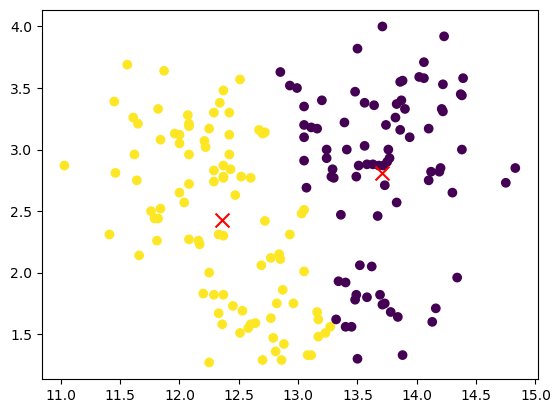

Sanity Check 2 passed: True
3 Cluster Plot:


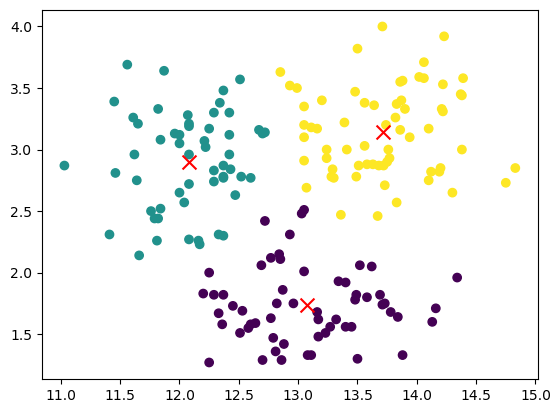

In [7]:
# Use this code block to test your implementation in Problem 1.4
# Don't change anything here -- just run it

# I changed the color from berlin to viridis

kmeans = KMeansClustering(2, 'random', random_state=seed)
kmeans.fit(X)
expected = np.array([[13.70329412, 2.81270588], [12.3583871, 2.42795699]])
print(f'Sanity Check 1 passed: {np.allclose(kmeans.centroids, expected, rtol=1e-3, atol=1e-3)}')
print('2 Cluster Plot:')
plt.scatter(X[:, 0], X[:, 1], c=kmeans.compute_memberships(X, kmeans.centroids)[0], cmap='viridis')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', s=100, marker='x')
plt.show()

kmeans = KMeansClustering(3, 'random', random_state=seed)
kmeans.fit(X)
expected = np.array([[13.07413793, 1.73741379], [12.07981818, 2.90290909], [13.71415385, 3.14538462]])
print(f'Sanity Check 2 passed: {np.allclose(kmeans.centroids, expected, rtol=1e-3, atol=1e-3)}')
print('3 Cluster Plot:')
plt.scatter(X[:, 0], X[:, 1], c=kmeans.compute_memberships(X, kmeans.centroids)[0], cmap='viridis')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', s=100, marker='x')
plt.show()

## Problem 2: Experiments

Now that you've implemented the k-means clustering algorithm, you will experiment with your implementation on a toy dataset. The function `sample_data` below will generate some synthetic (i.e. made-up) data for you to experiment with. In addition, you are provided with a function `plot_decision_boundary`. This function takes in a *trained* `KMeansClassifier` object and a dataset `X`, and plots the resulting decision boundaries.

In [8]:
def sample_data(n_clusters, n_samples_per_cluster=100, random_state=None):
    """
    Samples a synthetic dataset with n_clusters.
    """
    np.random.seed(random_state)
    dtheta = 2*np.pi/n_clusters

    samples_all = []
    r = 1.
    sigma = 0.1
    for n in range(n_clusters):
        theta = n * dtheta
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        samples = np.random.randn(n_samples_per_cluster, 2)
        samples = sigma * samples + np.array([x,y])
        samples_all.append(samples)

    samples_all = np.asarray(samples_all).reshape(-1, 2)
    return samples_all

In [9]:
def plot_decision_boundary(kmeans, X):
    """
    Plots the decision boundary for a KMeansClassifier object that was trained on a dataset X.
    """
    # Create an sklearn KMeans object
    sklearn_kmeans = KMeans(n_clusters=kmeans.k)
    # We aren't actually using the results of this fit method -- just initializing it
    sklearn_kmeans.fit(X)
    # Set the sklearn_kmeans centroids to those found by your implementation
    sklearn_kmeans.cluster_centers_ = kmeans.centroids
    # Plot the decision boundary
    decision_boundary = DecisionBoundaryDisplay.from_estimator(sklearn_kmeans, X, alpha=0.4, grid_resolution=250, response_method="predict")
    # Plot the training data
    decision_boundary.ax_.scatter(*X.T, edgecolor='k', marker='o', label='data')
    # Plot the clusters
    decision_boundary.ax_.scatter(*kmeans.centroids.T, label='centroids', edgecolor='k', color='red', marker='x', s=64)
    plt.title(f"k = {kmeans.k}")
    plt.legend()
    plt.show()

In this next line, we'll create a dataset with 6 distinct clusters. Note that we set `random_state=seed` for reproducibility. Be sure to run this line of code in order to create our dataset.

In [10]:
X_sample = sample_data(6, random_state=seed)

<!-- BEGIN QUESTION -->

### Problem 2.1 Varying k

- Fit a `KMeansClustering` object on `X_sample` for every value of `k = [2, 4, 6, 8]`. Use the initialization strategy `random` and make sure to set `random_state=seed` in `KMeansClustering`.
- For each of these values of `k`, plot the resulting decision boundary using the provided function `plot_decision_boundary`.
- Include a short description (1-2 sentences) of what you see happen as you increase `k`.

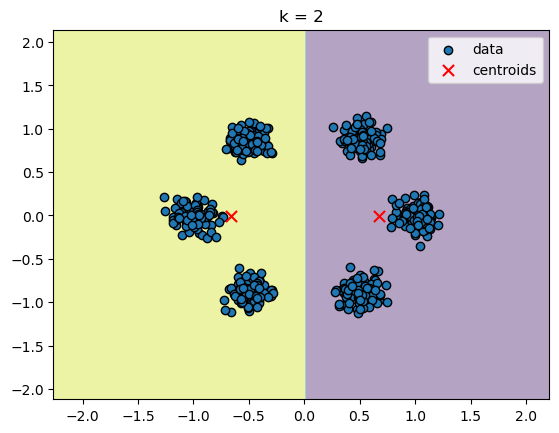

In [11]:
#k = 2
kmeans_2 = KMeansClustering(k=2, init_strategy='random', random_state=seed)
kmeans_2.fit(X_sample)
plot_decision_boundary(kmeans_2, X_sample)

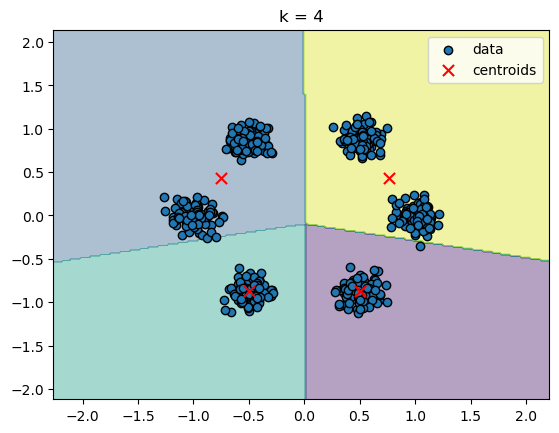

In [12]:
# k = 4
kmeans_4 = KMeansClustering(k=4, init_strategy='random', random_state=seed)
kmeans_4.fit(X_sample)
plot_decision_boundary(kmeans_4, X_sample)

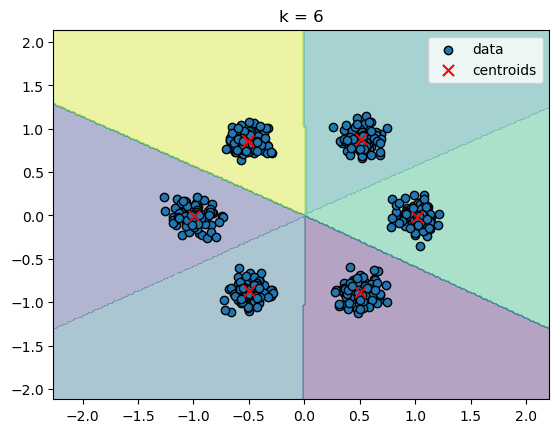

In [13]:
# k = 6
kmeans_6 = KMeansClustering(k=6, init_strategy='random', random_state=seed)
kmeans_6.fit(X_sample)
plot_decision_boundary(kmeans_6, X_sample)

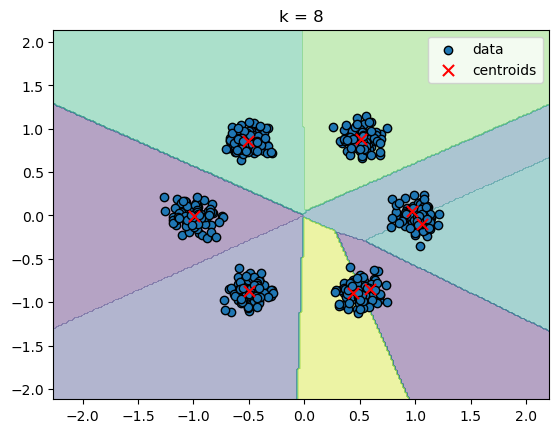

In [14]:
# k = 8
kmeans_8 = KMeansClustering(k=8, init_strategy='random', random_state=seed)
kmeans_8.fit(X_sample)
plot_decision_boundary(kmeans_8, X_sample)

At low k (e.g., k=2): The algorithm divides the data into broad regions, combining multiple distinct clusters into one. The decision boundaries are coarse and may not capture the true structure of the data.

As k increases (e.g., k=4, 6): The centroids become more localized, and the clusters better match the actual data groupings. The decision boundaries more accurately reflect the natural structure in the data.

At high k (e.g., k=8): The algorithm may start to overfit by creating clusters within natural groups. It captures fine-grained differences, but might split a natural cluster into multiple smaller clusters.

Increasing k makes the clustering more granular. Initially, this improves fit to the data's structure, but beyond a certain point it may lead to overfitting, where natural groupings are unnecessarily divided.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Problem 2.2: Random initialization 

In your implementation of `KMeansClustering`, you implemented two initialization strategies: random and k-means++. In this problem, you will see the effect that the initialization strategy can have on the resulting clusters. You will fit several `KMeansClustering` objects, each having the same number of clusters, but a different random seed -- thus, you will be simulating several initializations, and seeing their effect on the clusters.

- Fit a `KMeansClustering` object on `X_sample` with 6 clusters for each fo the following values of `random_state = [5, 6, 7, 8]`. Use the initialization strategy `random`.
- For each of these random initializations, plot the resulting decision boundary using the provided function `plot_decision_boundary`.
- Include a short description (1-2 sentences) of what you see happen.

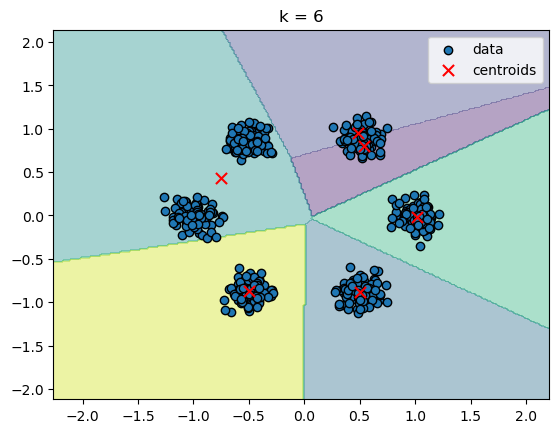

In [15]:
# random_state = 5

kmeans_5 = KMeansClustering(k=6, init_strategy='random', random_state=5)
kmeans_5.fit(X_sample)
plot_decision_boundary(kmeans_5, X_sample)

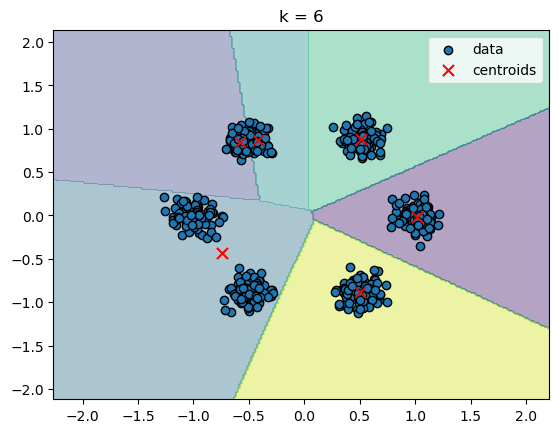

In [16]:
# random_state = 6

kmeans_6 = KMeansClustering(k=6, init_strategy='random', random_state=6)
kmeans_6.fit(X_sample)
plot_decision_boundary(kmeans_6, X_sample)

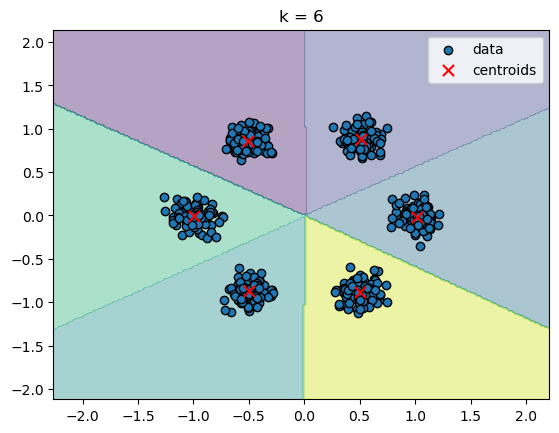

In [17]:
# random_state = 7
kmeans_7 = KMeansClustering(k=6, init_strategy='random', random_state=7)
kmeans_7.fit(X_sample)
plot_decision_boundary(kmeans_7, X_sample)

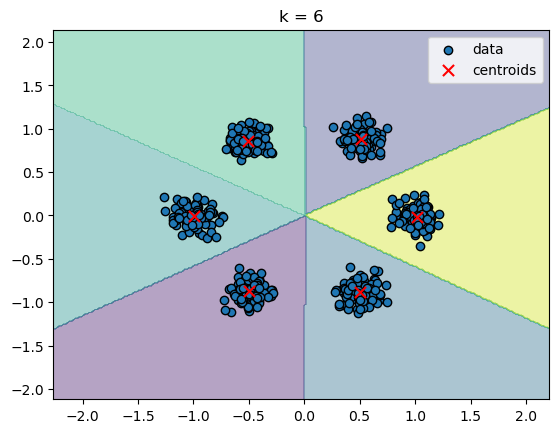

In [18]:
# random_state = 8

kmeans_8 = KMeansClustering(k=6, init_strategy='random', random_state=8)
kmeans_8.fit(X_sample)
plot_decision_boundary(kmeans_8, X_sample)

Random initialization can lead to inconsistent and sometimes suboptimal clustering results, especially when centroids are poorly initialized. This highlights the importance of smart initialization strategies like k-means++ to achieve more stable and accurate clustering.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Problem 2.3: Kmeans++ initialization

You will now do the same thing as in Problem 2.2, but with the k-means++ initialization strategy.

- Fit a `KMeansClustering` object on `X_sample` with 6 clusters for each fo the following values of `random_state = [5, 6, 7, 8]`. Use the initialization strategy `kmeans++`.
- For each of these random initializations, plot the resulting decision boundary using the provided function `plot_decision_boundary`.
- Include a short description (1-2 sentences) of what you see happen. Be sure to compare your results with the initialization strategy `random` to your results with the initialization strategy `kmeans++`.

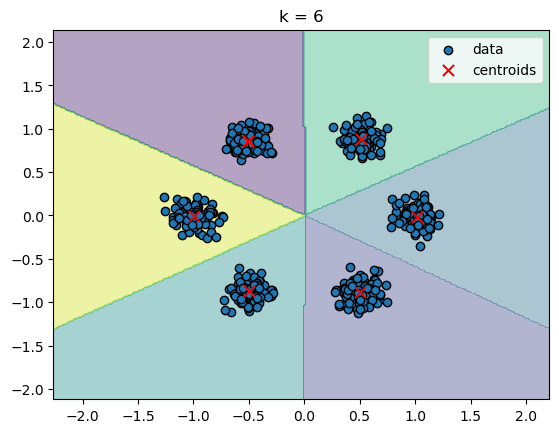

In [19]:
# random_state = 5
kmeans_5_pp = KMeansClustering(k=6, init_strategy='kmeans++', random_state=5)
kmeans_5_pp.fit(X_sample)
plot_decision_boundary(kmeans_5_pp, X_sample)

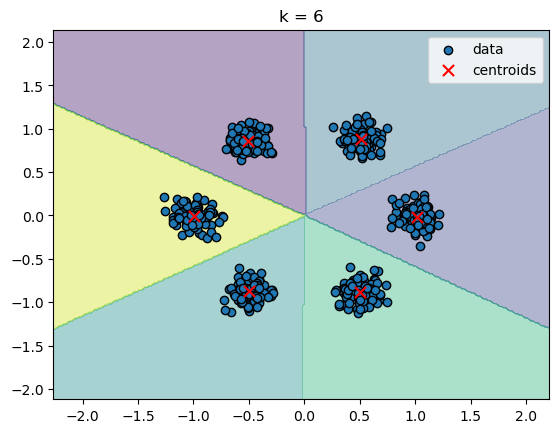

In [20]:
# random_state = 6

kmeans_6_pp = KMeansClustering(k=6, init_strategy='kmeans++', random_state=6)
kmeans_6_pp.fit(X_sample)
plot_decision_boundary(kmeans_6_pp, X_sample)

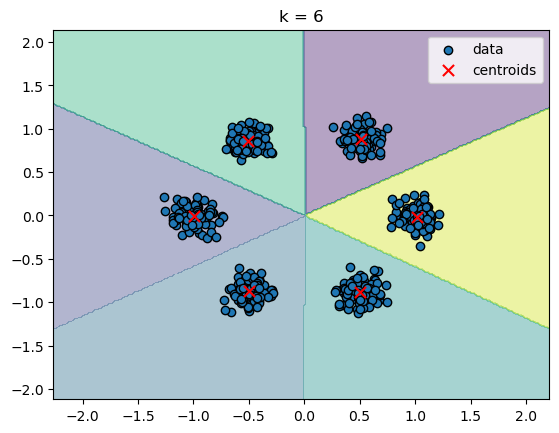

In [21]:
# random_state = 7

kmeans_7_pp = KMeansClustering(k=6, init_strategy='kmeans++', random_state=7)
kmeans_7_pp.fit(X_sample)
plot_decision_boundary(kmeans_7_pp, X_sample)

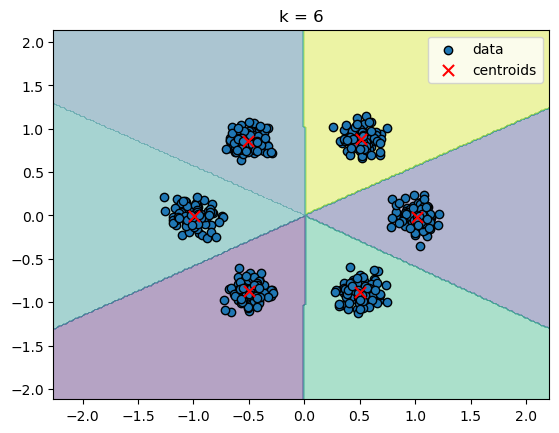

In [22]:
# random_state = 8
kmeans_8_pp = KMeansClustering(k=6, init_strategy='kmeans++', random_state=8)
kmeans_8_pp.fit(X_sample)
plot_decision_boundary(kmeans_8_pp, X_sample)

From the four plots generated using k-means++ initialization with k = 6 and different random_state values (5, 6, 7, 8), we observe:

All four runs show consistent and accurate clustering, where each centroid is well-aligned with a distinct data cluster.

The resulting decision boundaries are clean and symmetrical, with very little variation between runs.

Comparison to Random Initialization:
Unlike random initialization (which sometimes placed centroids poorly and led to irregular clusters), k-means++ consistently avoids bad initializations by spreading out initial centroids based on data distribution.

This leads to more stable and optimal clustering outcomes across different seeds.

The kmeans++ initialization strategy significantly improves clustering performance and consistency over random initialization, especially when the number of clusters matches the number of natural groupings in the data.

<!-- END QUESTION -->

